In [1]:
from collections import defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import (
    AutoImageProcessor,
    DeiTForImageClassificationWithTeacher,
    ViTForImageClassification,
)

sns.set_theme(style="whitegrid")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = choose_device()
print(f"Using device: {device}")


Using device: cuda


In [2]:
@dataclass(frozen=True)
class ModelSpec:
    name: str
    repo_id: str
    imagenet_top1: float
    imagenet_top5: float
    params: str
    is_distilled: bool = False


MODEL_SPECS: List[ModelSpec] = [
    ModelSpec("DeiT-tiny", "facebook/deit-tiny-patch16-224", 72.2, 91.1, "5M"),
    ModelSpec("DeiT-small", "facebook/deit-small-patch16-224", 79.9, 95.0, "22M"),
    ModelSpec("DeiT-base", "facebook/deit-base-patch16-224", 81.8, 95.6, "86M"),
    ModelSpec("DeiT-tiny distilled", "facebook/deit-tiny-distilled-patch16-224", 74.5, 91.9, "6M", True),
    ModelSpec("DeiT-small distilled", "facebook/deit-small-distilled-patch16-224", 81.2, 95.4, "22M", True),
    ModelSpec("DeiT-base distilled", "facebook/deit-base-distilled-patch16-224", 83.4, 96.5, "87M", True),
    ModelSpec("DeiT-base 384", "facebook/deit-base-patch16-384", 82.9, 96.2, "87M"),
    ModelSpec("DeiT-base distilled 384", "facebook/deit-base-distilled-patch16-384", 85.2, 97.2, "88M", True),
]

EXPERIMENT_CONFIG = {
    "dataset_name": "pouya-haghi/imagenet-1k",
    "split": "train",
    "selected_model_names": [spec.name for spec in MODEL_SPECS],
    "contribution_max_samples": 1000,
    "contribution_batch_size": 4,
    "contribution_batch_size_384": 1,
    "accuracy_batch_size": 16,
    "noise_eval_samples": 500,
    "alphas": [0.0, 0.25, 0.5, 0.75, 1.0],
    "noise_target_layers": [8, 9, 10],
    "fragility_target_layers": None,
    "results_dir": "standardized_results",
    "show_progress": True,
}

pd.DataFrame([asdict(spec) for spec in MODEL_SPECS])


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [3]:
def slugify(value: str) -> str:
    return value.lower().replace("-", "_").replace(" ", "_")


def select_model_specs(selected_names: Optional[Sequence[str]] = None) -> List[ModelSpec]:
    if not selected_names:
        return MODEL_SPECS

    selected_name_set = set(selected_names)
    selected = [spec for spec in MODEL_SPECS if spec.name in selected_name_set]
    missing = sorted(selected_name_set - {spec.name for spec in selected})
    if missing:
        raise ValueError(f"Unknown model names: {missing}")
    return selected


def get_model_class(spec: ModelSpec):
    if spec.is_distilled:
        return DeiTForImageClassificationWithTeacher
    return ViTForImageClassification


def get_layer_stack(model):
    if hasattr(model, "deit"):
        return model.deit.encoder.layer
    if hasattr(model, "vit"):
        return model.vit.encoder.layer
    raise AttributeError("Unsupported model architecture: expected a `deit` or `vit` encoder stack.")


def get_contribution_batch_size(spec: ModelSpec, config: Dict) -> int:
    if "384" in spec.repo_id:
        return config.get("contribution_batch_size_384", 1)
    return config["contribution_batch_size"]


def load_model_and_processor(spec: ModelSpec):
    processor = AutoImageProcessor.from_pretrained(spec.repo_id, use_fast=True)
    model_cls = get_model_class(spec)
    model = model_cls.from_pretrained(spec.repo_id, attn_implementation="eager")
    model = model.to(device).eval()
    return model, processor


def build_accuracy_batches(dataset_split, processor, batch_size: int, max_samples: Optional[int] = None, show_progress: bool = True):
    total_samples = len(dataset_split) if max_samples is None else min(max_samples, len(dataset_split))
    batches = []

    iterator = range(0, total_samples, batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Encoding accuracy batches", leave=False)

    for start_idx in iterator:
        batch = dataset_split[start_idx : start_idx + batch_size]
        images = [image.convert("RGB") for image in batch["image"]]
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}
        labels = torch.tensor(batch["label"], device=device)
        batches.append((inputs, labels))

    return batches, total_samples


@torch.inference_mode()
def evaluate_accuracy(model, eval_batches, show_progress: bool = False, desc: str = "Evaluating") -> float:
    correct = 0
    total = 0

    iterator = eval_batches
    if show_progress:
        iterator = tqdm(eval_batches, desc=desc, leave=False)

    for inputs, labels in iterator:
        logits = model(**inputs).logits
        predictions = logits.argmax(dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    return round(100.0 * correct / total, 2)


def cleanup_model(*objects) -> None:
    for obj in objects:
        del obj
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()


In [4]:
LAYER_METRICS = [
    "residual_norm",
    "attention_output_norm",
    "ffn_output_norm",
    "layer_output_norm",
    "attn_relative_contribution",
    "ffn_relative_contribution",
    "representation_change",
]


def run_attention_block(module, hidden_states: torch.Tensor, head_mask=None) -> torch.Tensor:
    call_patterns = [
        lambda: module.attention(hidden_states, head_mask, output_attentions=False),
        lambda: module.attention(hidden_states, head_mask),
        lambda: module.attention(hidden_states),
    ]

    last_error = None
    for call_pattern in call_patterns:
        try:
            attention_outputs = call_pattern()
            if isinstance(attention_outputs, tuple):
                return attention_outputs[0]
            return attention_outputs
        except TypeError as exc:
            last_error = exc

    raise last_error


def compute_layer_contribution_tensors(module, hidden_states: torch.Tensor, head_mask=None) -> Dict[str, torch.Tensor]:
    eps = 1e-12

    hidden_states_norm = module.layernorm_before(hidden_states)
    attention_output = run_attention_block(module, hidden_states_norm, head_mask)

    residual_stream = attention_output + hidden_states
    layer_output_norm = module.layernorm_after(residual_stream)
    intermediate_output = module.intermediate(layer_output_norm)
    ffn_output = module.output.dense(intermediate_output)
    ffn_output = module.output.dropout(ffn_output)
    layer_output = ffn_output + residual_stream

    h_input = hidden_states[:, 0, :]
    attn_cls = attention_output[:, 0, :]
    ffn_cls = ffn_output[:, 0, :]
    h_output = layer_output[:, 0, :]

    h_input_norm = h_input.norm(dim=-1).clamp_min(eps)
    attn_norm = attn_cls.norm(dim=-1)
    ffn_norm = ffn_cls.norm(dim=-1)
    h_output_norm = h_output.norm(dim=-1)

    return {
        "residual_norm": h_input_norm.detach().cpu(),
        "attention_output_norm": attn_norm.detach().cpu(),
        "ffn_output_norm": ffn_norm.detach().cpu(),
        "layer_output_norm": h_output_norm.detach().cpu(),
        "attn_relative_contribution": (attn_norm / h_input_norm).detach().cpu(),
        "ffn_relative_contribution": (ffn_norm / h_input_norm).detach().cpu(),
        "representation_change": ((h_output - h_input).norm(dim=-1) / h_input_norm).detach().cpu(),
    }


def collect_contribution_records(model, processor, dataset_split, max_samples: int, batch_size: int, show_progress: bool = True) -> pd.DataFrame:
    rows = []
    layer_metrics = {}
    handles = []

    def make_hook(layer_idx: int):
        def hook(module, inputs, output):
            hidden_states = inputs[0]
            head_mask = inputs[1] if len(inputs) > 1 else None
            layer_metrics[layer_idx] = compute_layer_contribution_tensors(module, hidden_states, head_mask)
        return hook

    for layer_idx, layer in enumerate(get_layer_stack(model)):
        handles.append(layer.register_forward_hook(make_hook(layer_idx)))

    total_samples = min(max_samples, len(dataset_split))
    iterator = range(0, total_samples, batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Collecting layer contributions", leave=False)

    try:
        for start_idx in iterator:
            batch = dataset_split[start_idx : start_idx + batch_size]
            images = [image.convert("RGB") for image in batch["image"]]
            labels = torch.tensor(batch["label"], dtype=torch.long)
            inputs = processor(images=images, return_tensors="pt")
            inputs = {key: value.to(device) for key, value in inputs.items()}

            layer_metrics.clear()
            with torch.inference_mode():
                outputs = model(**inputs)
                predictions = outputs.logits.argmax(dim=-1).cpu()

            for local_idx, label in enumerate(labels.tolist()):
                prediction = int(predictions[local_idx].item())
                is_correct = prediction == label

                for layer_idx in sorted(layer_metrics):
                    row = {
                        "sample_index": start_idx + local_idx,
                        "layer": layer_idx,
                        "label": label,
                        "prediction": prediction,
                        "is_correct": is_correct,
                    }
                    for metric in LAYER_METRICS:
                        row[metric] = float(layer_metrics[layer_idx][metric][local_idx].item())
                    rows.append(row)

            del outputs, predictions, inputs, labels, images, batch
            layer_metrics.clear()
            if device.type == "cuda":
                torch.cuda.empty_cache()
    finally:
        for handle in handles:
            handle.remove()

    return pd.DataFrame(rows)


def aggregate_contribution_records(records_df: pd.DataFrame) -> pd.DataFrame:
    if records_df.empty:
        return records_df

    summaries = []
    split_frames = {
        "all": records_df,
        "correct": records_df[records_df["is_correct"]],
        "incorrect": records_df[~records_df["is_correct"]],
    }

    for split_name, split_df in split_frames.items():
        if split_df.empty:
            continue
        melted = split_df.melt(id_vars=["layer"], value_vars=LAYER_METRICS, var_name="metric", value_name="value")
        summary = melted.groupby(["layer", "metric"], as_index=False).agg(
            mean=("value", "mean"),
            std=("value", "std"),
            count=("value", "size"),
        )
        summary["split"] = split_name
        summaries.append(summary)

    return pd.concat(summaries, ignore_index=True)


def build_dashboard_arrays(records_df: pd.DataFrame):
    if records_df.empty:
        raise ValueError("No records available for plotting.")

    layers = sorted(records_df["layer"].unique())
    aggregated = {metric: {"mean": [], "std": []} for metric in LAYER_METRICS}

    for metric in LAYER_METRICS:
        for layer_idx in layers:
            values = records_df.loc[records_df["layer"] == layer_idx, metric].to_numpy()
            aggregated[metric]["mean"].append(float(np.mean(values)))
            aggregated[metric]["std"].append(float(np.std(values)))

    cumulative = records_df.pivot(index="sample_index", columns="layer", values="representation_change")
    cumulative = cumulative.reindex(columns=layers).cumsum(axis=1)

    return layers, aggregated, cumulative.mean(axis=0).to_numpy(), cumulative.std(axis=0).to_numpy()


In [5]:
def run_contribution_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict):
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    raw_frames = []
    summary_frames = []

    for spec in model_specs:
        contribution_batch_size = get_contribution_batch_size(spec, config)
        print(f"Running contribution analysis for {spec.name} with batch_size={contribution_batch_size}...")
        model, processor = load_model_and_processor(spec)
        raw_df = collect_contribution_records(
            model=model,
            processor=processor,
            dataset_split=dataset_split,
            max_samples=config["contribution_max_samples"],
            batch_size=contribution_batch_size,
            show_progress=config["show_progress"],
        )
        raw_df.insert(0, "repo_id", spec.repo_id)
        raw_df.insert(0, "model_name", spec.name)

        summary_df = aggregate_contribution_records(raw_df)
        summary_df.insert(0, "repo_id", spec.repo_id)
        summary_df.insert(0, "model_name", spec.name)

        raw_df.to_csv(results_dir / f"{slugify(spec.name)}_contribution_raw.csv", index=False)
        summary_df.to_csv(results_dir / f"{slugify(spec.name)}_contribution_summary.csv", index=False)

        raw_frames.append(raw_df)
        summary_frames.append(summary_df)
        cleanup_model(model, processor)

    return pd.concat(raw_frames, ignore_index=True), pd.concat(summary_frames, ignore_index=True)


def _get_dashboard_split(raw_df: pd.DataFrame, model_name: str, split: str = "all"):
    model_df = raw_df[raw_df["model_name"] == model_name].copy()
    if split == "correct":
        model_df = model_df[model_df["is_correct"]]
    elif split == "incorrect":
        model_df = model_df[~model_df["is_correct"]]
    elif split != "all":
        raise ValueError("split must be one of: all, correct, incorrect")

    if model_df.empty:
        return None

    layers, aggregated, cumulative_mean, cumulative_std = build_dashboard_arrays(model_df)
    return {
        "layers": np.array(layers),
        "aggregated": aggregated,
        "cumulative_mean": np.array(cumulative_mean),
        "cumulative_std": np.array(cumulative_std),
        "sample_count": model_df["sample_index"].nunique(),
    }



def plot_layer_contribution_report(
    raw_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    models_per_figure: int = 2,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]

    for start in range(0, len(model_names), models_per_figure):
        batch = model_names[start : start + models_per_figure]
        fig, axes = plt.subplots(len(batch), 4, figsize=(24, 5 * len(batch)), squeeze=False)

        for row, model_name in enumerate(batch):
            all_split = _get_dashboard_split(raw_df, model_name, split="all")
            correct_split = _get_dashboard_split(raw_df, model_name, split="correct")
            incorrect_split = _get_dashboard_split(raw_df, model_name, split="incorrect")

            if all_split is None:
                for ax in axes[row]:
                    ax.axis("off")
                continue

            ax_norms, ax_relative, ax_change, ax_cumulative = axes[row]
            layers = all_split["layers"]
            aggregated = all_split["aggregated"]

            for key, color, marker, label in [
                ("residual_norm", "b", "o", "Residual stream (input)"),
                ("attention_output_norm", "r", "s", "Attention output"),
                ("ffn_output_norm", "g", "^", "FFN output"),
            ]:
                mean = np.array(aggregated[key]["mean"])
                std = np.array(aggregated[key]["std"])
                ax_norms.plot(layers, mean, f"{color}-{marker}", label=label)
                ax_norms.fill_between(layers, mean - std, mean + std, color=color, alpha=0.18)
            ax_norms.set_title(f"{model_name}: Absolute norms")
            ax_norms.set_xlabel("Layer")
            ax_norms.set_ylabel("Norm")
            ax_norms.legend(fontsize=9)

            for key, color, marker, label in [
                ("attn_relative_contribution", "r", "s", "Attention / Residual"),
                ("ffn_relative_contribution", "g", "^", "FFN / Residual"),
            ]:
                mean = np.array(aggregated[key]["mean"])
                std = np.array(aggregated[key]["std"])
                ax_relative.plot(layers, mean, f"{color}-{marker}", label=label)
                ax_relative.fill_between(layers, mean - std, mean + std, color=color, alpha=0.18)
            ax_relative.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
            ax_relative.set_title("Relative contribution")
            ax_relative.set_xlabel("Layer")
            ax_relative.set_ylabel("Contribution / residual")
            ax_relative.legend(fontsize=9)

            all_change_mean = np.array(aggregated["representation_change"]["mean"])
            all_change_std = np.array(aggregated["representation_change"]["std"])
            bar_width = 0.35
            ax_change.plot(layers, all_change_mean, "k--o", label=f"All (N={all_split['sample_count']})")
            ax_change.fill_between(
                layers,
                all_change_mean - all_change_std,
                all_change_mean + all_change_std,
                color="gray",
                alpha=0.15,
            )
            if correct_split is not None:
                correct_change = np.array(correct_split["aggregated"]["representation_change"]["mean"])
                ax_change.bar(
                    correct_split["layers"] - bar_width / 2,
                    correct_change,
                    width=bar_width,
                    color="#27ae60",
                    alpha=0.65,
                    label=f"Correct (N={correct_split['sample_count']})",
                )
            if incorrect_split is not None:
                incorrect_change = np.array(incorrect_split["aggregated"]["representation_change"]["mean"])
                ax_change.bar(
                    incorrect_split["layers"] + bar_width / 2,
                    incorrect_change,
                    width=bar_width,
                    color="#e74c3c",
                    alpha=0.65,
                    label=f"Incorrect (N={incorrect_split['sample_count']})",
                )
            ax_change.set_title("Representation change by outcome")
            ax_change.set_xlabel("Layer")
            ax_change.set_ylabel("||h_out - h_in|| / ||h_in||")
            ax_change.legend(fontsize=9)

            ax_cumulative.plot(
                layers,
                all_split["cumulative_mean"],
                "k-o",
                label=f"All (N={all_split['sample_count']})",
            )
            ax_cumulative.fill_between(
                layers,
                all_split["cumulative_mean"] - all_split["cumulative_std"],
                all_split["cumulative_mean"] + all_split["cumulative_std"],
                color="gray",
                alpha=0.15,
            )
            if correct_split is not None:
                ax_cumulative.plot(
                    correct_split["layers"],
                    correct_split["cumulative_mean"],
                    color="#27ae60",
                    marker="o",
                    label=f"Correct (N={correct_split['sample_count']})",
                )
            if incorrect_split is not None:
                ax_cumulative.plot(
                    incorrect_split["layers"],
                    incorrect_split["cumulative_mean"],
                    color="#e74c3c",
                    marker="o",
                    label=f"Incorrect (N={incorrect_split['sample_count']})",
                )
            ax_cumulative.set_title("Cumulative representation change")
            ax_cumulative.set_xlabel("Layer")
            ax_cumulative.set_ylabel("Cumulative change")
            ax_cumulative.legend(fontsize=9)

        plt.tight_layout()
        plt.suptitle(
            f"Layer contribution report ({start + 1}-{start + len(batch)} of {len(model_names)} models)",
            y=1.02,
        )
        plt.show()



def plot_cumulative_representation_change_comparison(
    raw_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    split: str = "all",
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    palette = sns.color_palette("tab10", n_colors=len(model_names))

    plt.figure(figsize=(13, 8))
    plotted_models = 0

    for color, model_name in zip(palette, model_names):
        split_data = _get_dashboard_split(raw_df, model_name, split=split)
        if split_data is None:
            continue

        plt.plot(
            split_data["layers"],
            split_data["cumulative_mean"],
            marker="o",
            linewidth=2,
            color=color,
            label=f"{model_name} (N={split_data['sample_count']})",
        )
        plt.fill_between(
            split_data["layers"],
            split_data["cumulative_mean"] - split_data["cumulative_std"],
            split_data["cumulative_mean"] + split_data["cumulative_std"],
            color=color,
            alpha=0.12,
        )
        plotted_models += 1

    if plotted_models == 0:
        raise ValueError(f"No data available for split={split!r}.")

    plt.title(f"Cumulative representation change across models ({split})")
    plt.xlabel("Layer")
    plt.ylabel("Cumulative change")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()


In [16]:
def select_layer_parameters(model, target_layers: Sequence[int]):
    return {
        name: param
        for name, param in model.named_parameters()
        if any(f"layer.{layer_idx}." in name for layer_idx in target_layers)
    }


def snapshot_parameters(parameters: Dict[str, torch.nn.Parameter]):
    return {name: param.detach().clone() for name, param in parameters.items()}


def restore_parameters(parameters: Dict[str, torch.nn.Parameter], snapshot: Dict[str, torch.Tensor]) -> None:
    with torch.no_grad():
        for name, param in parameters.items():
            param.copy_(snapshot[name])


def apply_interpolated_noise(parameters: Dict[str, torch.nn.Parameter], snapshot: Dict[str, torch.Tensor], alpha: float) -> None:
    with torch.no_grad():
        for name, param in parameters.items():
            trained_weight = snapshot[name]
            mean = trained_weight.mean()
            std = trained_weight.std(unbiased=False)
            if std.item() == 0:
                random_weight = torch.randn_like(trained_weight) + mean
            else:
                random_weight = torch.randn_like(trained_weight) * std + mean
            blended = alpha * random_weight + (1 - alpha) * trained_weight
            param.copy_(blended)


def run_noise_robustness_experiment(spec: ModelSpec, dataset_split, config: Dict, target_layers: Optional[Sequence[int]] = None) -> pd.DataFrame:
    target_layers = list(config["noise_target_layers"] if target_layers is None else target_layers)
    model, processor = load_model_and_processor(spec)
    eval_batches, total_samples = build_accuracy_batches(
        dataset_split,
        processor,
        batch_size=config["accuracy_batch_size"],
        max_samples=config["noise_eval_samples"],
        show_progress=config["show_progress"],
    )

    layer_parameters = select_layer_parameters(model, target_layers)
    original_weights = snapshot_parameters(layer_parameters)
    rows = []
    baseline_accuracy = None

    for alpha in config["alphas"]:
        restore_parameters(layer_parameters, original_weights)
        apply_interpolated_noise(layer_parameters, original_weights, alpha)
        accuracy = evaluate_accuracy(model, eval_batches, show_progress=False)
        if baseline_accuracy is None:
            baseline_accuracy = accuracy
        rows.append({
            "model_name": spec.name,
            "repo_id": spec.repo_id,
            "target_layers": list(target_layers),
            "alpha": alpha,
            "accuracy": accuracy,
            "baseline_accuracy": baseline_accuracy,
            "accuracy_drop": round(baseline_accuracy - accuracy, 2),
            "samples_evaluated": total_samples,
        })

    restore_parameters(layer_parameters, original_weights)
    cleanup_model(model, processor)
    return pd.DataFrame(rows)


def run_fragility_experiment(spec: ModelSpec, dataset_split, config: Dict, target_layers: Optional[Sequence[int]] = None) -> pd.DataFrame:
    model, processor = load_model_and_processor(spec)
    if target_layers is None:
        configured_layers = config.get("fragility_target_layers")
        if configured_layers is None:
            target_layers = list(range(len(get_layer_stack(model))))
        else:
            target_layers = list(configured_layers)
    else:
        target_layers = list(target_layers)

    eval_batches, total_samples = build_accuracy_batches(
        dataset_split,
        processor,
        batch_size=config["accuracy_batch_size"],
        max_samples=config["noise_eval_samples"],
        show_progress=config["show_progress"],
    )

    rows = []
    for layer_idx in target_layers:
        layer_parameters = select_layer_parameters(model, [layer_idx])
        original_weights = snapshot_parameters(layer_parameters)
        baseline_accuracy = None

        for alpha in config["alphas"]:
            restore_parameters(layer_parameters, original_weights)
            apply_interpolated_noise(layer_parameters, original_weights, alpha)
            accuracy = evaluate_accuracy(model, eval_batches, show_progress=False)
            if baseline_accuracy is None:
                baseline_accuracy = accuracy
            rows.append({
                "model_name": spec.name,
                "repo_id": spec.repo_id,
                "layer": layer_idx,
                "alpha": alpha,
                "accuracy": accuracy,
                "baseline_accuracy": baseline_accuracy,
                "accuracy_drop": round(baseline_accuracy - accuracy, 2),
                "samples_evaluated": total_samples,
            })

        restore_parameters(layer_parameters, original_weights)

    cleanup_model(model, processor)
    return pd.DataFrame(rows)


def run_noise_robustness_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict) -> pd.DataFrame:
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    for spec in model_specs:
        print(f"Running noise robustness for {spec.name}...")
        frame = run_noise_robustness_experiment(spec, dataset_split, config)
        frame.to_csv(results_dir / f"{slugify(spec.name)}_noise_robustness.csv", index=False)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


def run_fragility_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict) -> pd.DataFrame:
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    for spec in model_specs:
        print(f"Running layer fragility analysis for {spec.name}...")
        frame = run_fragility_experiment(spec, dataset_split, config)
        frame.to_csv(results_dir / f"{slugify(spec.name)}_fragility.csv", index=False)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


def plot_weight_noise_robustness_report(
    noise_results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    models_per_figure: int = 8,
    n_cols: int = 4,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]

    for start in range(0, len(model_names), models_per_figure):
        batch = model_names[start : start + models_per_figure]
        n_rows = int(np.ceil(len(batch) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.3 * n_cols, 4.2 * n_rows), squeeze=False)
        flat_axes = axes.flatten()

        for ax, model_name in zip(flat_axes, batch):
            noise_df = noise_results_df[noise_results_df["model_name"] == model_name].sort_values("alpha")
            if noise_df.empty:
                ax.set_visible(False)
                continue

            ax.plot(noise_df["alpha"], noise_df["accuracy"], color="#1f77b4", marker="o", linewidth=2)
            ax.axhline(
                y=noise_df["baseline_accuracy"].iloc[0],
                color="#7f8c8d",
                linestyle="--",
                linewidth=1.5,
            )
            ax.set_title(model_name)
            ax.set_xlabel("Alpha (0 = original, 1 = random)")
            ax.set_ylabel("Accuracy (%)")
            ax.grid(True, alpha=0.3)

        for ax in flat_axes[len(batch):]:
            ax.set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.suptitle(
            f"Weight noise robustness ({start + 1}-{start + len(batch)} of {len(model_names)} models)"
        )
        plt.show()



def plot_weight_noise_robustness_comparison(
    noise_results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    palette = sns.color_palette("tab10", n_colors=len(model_names))

    plt.figure(figsize=(13, 8))
    plotted_models = 0

    for color, model_name in zip(palette, model_names):
        noise_df = noise_results_df[noise_results_df["model_name"] == model_name].sort_values("alpha")
        if noise_df.empty:
            continue

        plt.plot(
            noise_df["alpha"],
            noise_df["accuracy"],
            marker="o",
            linewidth=2,
            color=color,
            label=model_name,
        )
        plotted_models += 1

    if plotted_models == 0:
        raise ValueError("No noise robustness data available for the selected models.")

    plt.title("Weight noise robustness across models")
    plt.xlabel("Alpha (0 = original, 1 = random)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()



def plot_fragility_line_report(
    fragility_results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    models_per_figure: int = 8,
    n_cols: int = 2,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    layer_values = sorted(fragility_results_df["layer"].unique())
    palette = dict(zip(layer_values, sns.color_palette("viridis", n_colors=len(layer_values))))

    for start in range(0, len(model_names), models_per_figure):
        batch = model_names[start : start + models_per_figure]
        n_rows = int(np.ceil(len(batch) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 4.5 * n_rows), squeeze=False)
        flat_axes = axes.flatten()
        legend_handles = None
        legend_labels = None

        for ax, model_name in zip(flat_axes, batch):
            fragility_df = fragility_results_df[fragility_results_df["model_name"] == model_name].copy()
            if fragility_df.empty:
                ax.set_visible(False)
                continue

            sns.lineplot(
                data=fragility_df.sort_values(["layer", "alpha"]),
                x="alpha",
                y="accuracy_drop",
                hue="layer",
                hue_order=layer_values,
                marker="o",
                linewidth=1.8,
                palette=palette,
                ax=ax,
                legend=legend_handles is None,
            )
            if legend_handles is None:
                legend = ax.get_legend()
                if legend is not None:
                    legend_handles = legend.legend_handles
                    legend_labels = [text.get_text() for text in legend.get_texts()]
                    legend.remove()

            ax.set_title(model_name)
            ax.set_xlabel("Noise level (alpha)")
            ax.set_ylabel("Accuracy drop (%)")
            ax.grid(True, alpha=0.3)

        for ax in flat_axes[len(batch):]:
            ax.set_visible(False)

        plt.suptitle(
            f"Layer fragility line plots ({start + 1}-{start + len(batch)} of {len(model_names)} models)",
            y=0.985,
        )

        if legend_handles is not None and legend_labels is not None:
            fig.legend(
                legend_handles,
                legend_labels,
                title="Layer",
                loc="upper center",
                bbox_to_anchor=(0.5, 0.955),
                ncol=min(6, len(legend_labels)),
                frameon=True,
            )

        plt.tight_layout(rect=[0, 0, 1, 0.84])
        plt.show()



def plot_fragility_overview_across_models(
    fragility_results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    alpha: Optional[float] = None,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    available_alphas = sorted(fragility_results_df["alpha"].unique())
    if alpha is None:
        alpha = float(available_alphas[-1])

    plot_df = fragility_results_df[
        (fragility_results_df["model_name"].isin(model_names))
        & np.isclose(fragility_results_df["alpha"], alpha)
    ].copy()

    if plot_df.empty:
        raise ValueError(f"No fragility data available for alpha={alpha}.")

    heatmap_df = plot_df.pivot(index="model_name", columns="layer", values="accuracy_drop")
    heatmap_df = heatmap_df.reindex(model_names)
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

    plt.figure(figsize=(max(12, len(heatmap_df.columns) * 0.75), max(4.5, len(model_names) * 0.7)))
    sns.heatmap(
        heatmap_df,
        cmap="rocket",
        annot=False,
        cbar_kws={"label": "Accuracy drop (%)"},
    )
    plt.title(f"Fragility across models and layers (alpha={alpha:g})")
    plt.xlabel("Layer")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()



def plot_fragility_layer_comparison(
    fragility_results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    layer_idx: Optional[int] = None,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    available_layers = sorted(
        fragility_results_df.loc[
            fragility_results_df["model_name"].isin(model_names),
            "layer",
        ].unique()
    )

    if len(available_layers) == 0:
        raise ValueError("No fragility data available for the selected models.")

    if layer_idx is None:
        layer_idx = 0 if 0 in available_layers else int(available_layers[0])
    elif layer_idx not in available_layers:
        fallback_layer = min(available_layers, key=lambda layer: abs(layer - layer_idx))
        print(
            f"Layer {layer_idx} not found in fragility results; using nearest available layer {fallback_layer}."
        )
        layer_idx = int(fallback_layer)

    plot_df = fragility_results_df[
        (fragility_results_df["model_name"].isin(model_names))
        & (fragility_results_df["layer"] == layer_idx)
    ].copy()

    if plot_df.empty:
        raise ValueError(f"No fragility data available for layer={layer_idx}.")

    plt.figure(figsize=(12, 7))
    sns.lineplot(
        data=plot_df,
        x="alpha",
        y="accuracy_drop",
        hue="model_name",
        hue_order=model_names,
        marker="o",
        linewidth=2,
    )
    plt.title(f"Layer {layer_idx} fragility across models")
    plt.xlabel("Noise level (alpha)")
    plt.ylabel("Accuracy drop (%)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()


In [7]:
selected_specs = select_model_specs(EXPERIMENT_CONFIG["selected_model_names"])
dataset_split = load_dataset(
    EXPERIMENT_CONFIG["dataset_name"],
    split=EXPERIMENT_CONFIG["split"],
)

print(f"Loaded {len(dataset_split):,} examples from {EXPERIMENT_CONFIG['dataset_name']}[{EXPERIMENT_CONFIG['split']!r}]")
pd.DataFrame([asdict(spec) for spec in selected_specs])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/43.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1024 [00:00<?, ? examples/s]

Loaded 1,024 examples from pouya-haghi/imagenet-1k['train']


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [8]:
contribution_raw_df, contribution_summary_df = run_contribution_suite(
    model_specs=selected_specs,
    dataset_split=dataset_split,
    config=EXPERIMENT_CONFIG,
)

contribution_summary_df.head()


Running contribution analysis for DeiT-tiny with batch_size=4...


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/351M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

,model_name,repo_id,layer,metric,mean,std,count,split
0,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attention_output_norm,8.654464,0.124599,1000,all
1,DeiT-tiny,facebook/deit-tiny-patch16-224,0,attn_relative_contribution,0.482817,0.006951,1000,all
2,DeiT-tiny,facebook/deit-tiny-patch16-224,0,ffn_output_norm,6.153107,0.070865,1000,all
3,DeiT-tiny,facebook/deit-tiny-patch16-224,0,ffn_relative_contribution,0.343271,0.003953,1000,all
4,DeiT-tiny,facebook/deit-tiny-patch16-224,0,layer_output_norm,16.492869,0.051765,1000,all


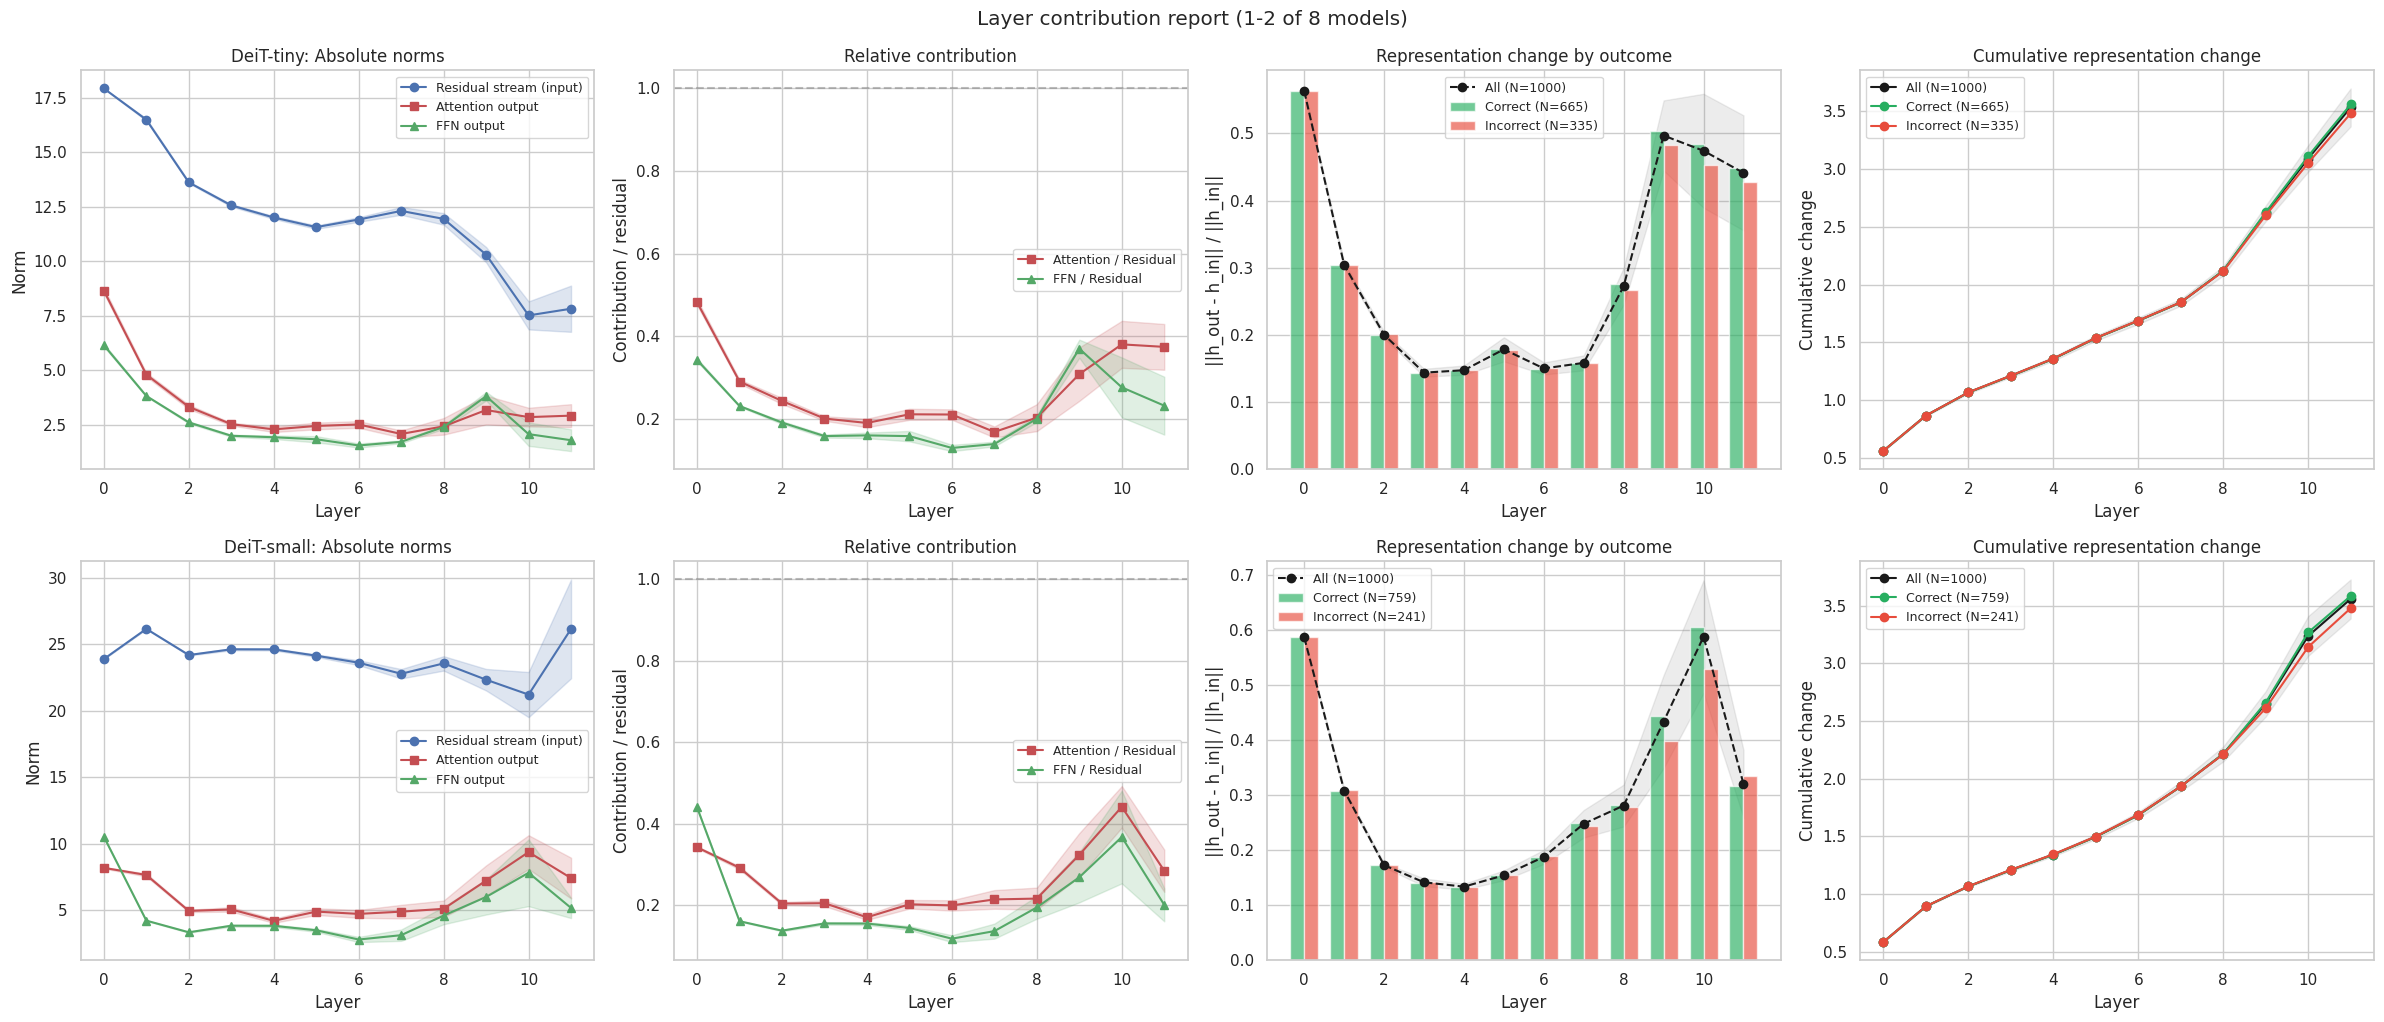

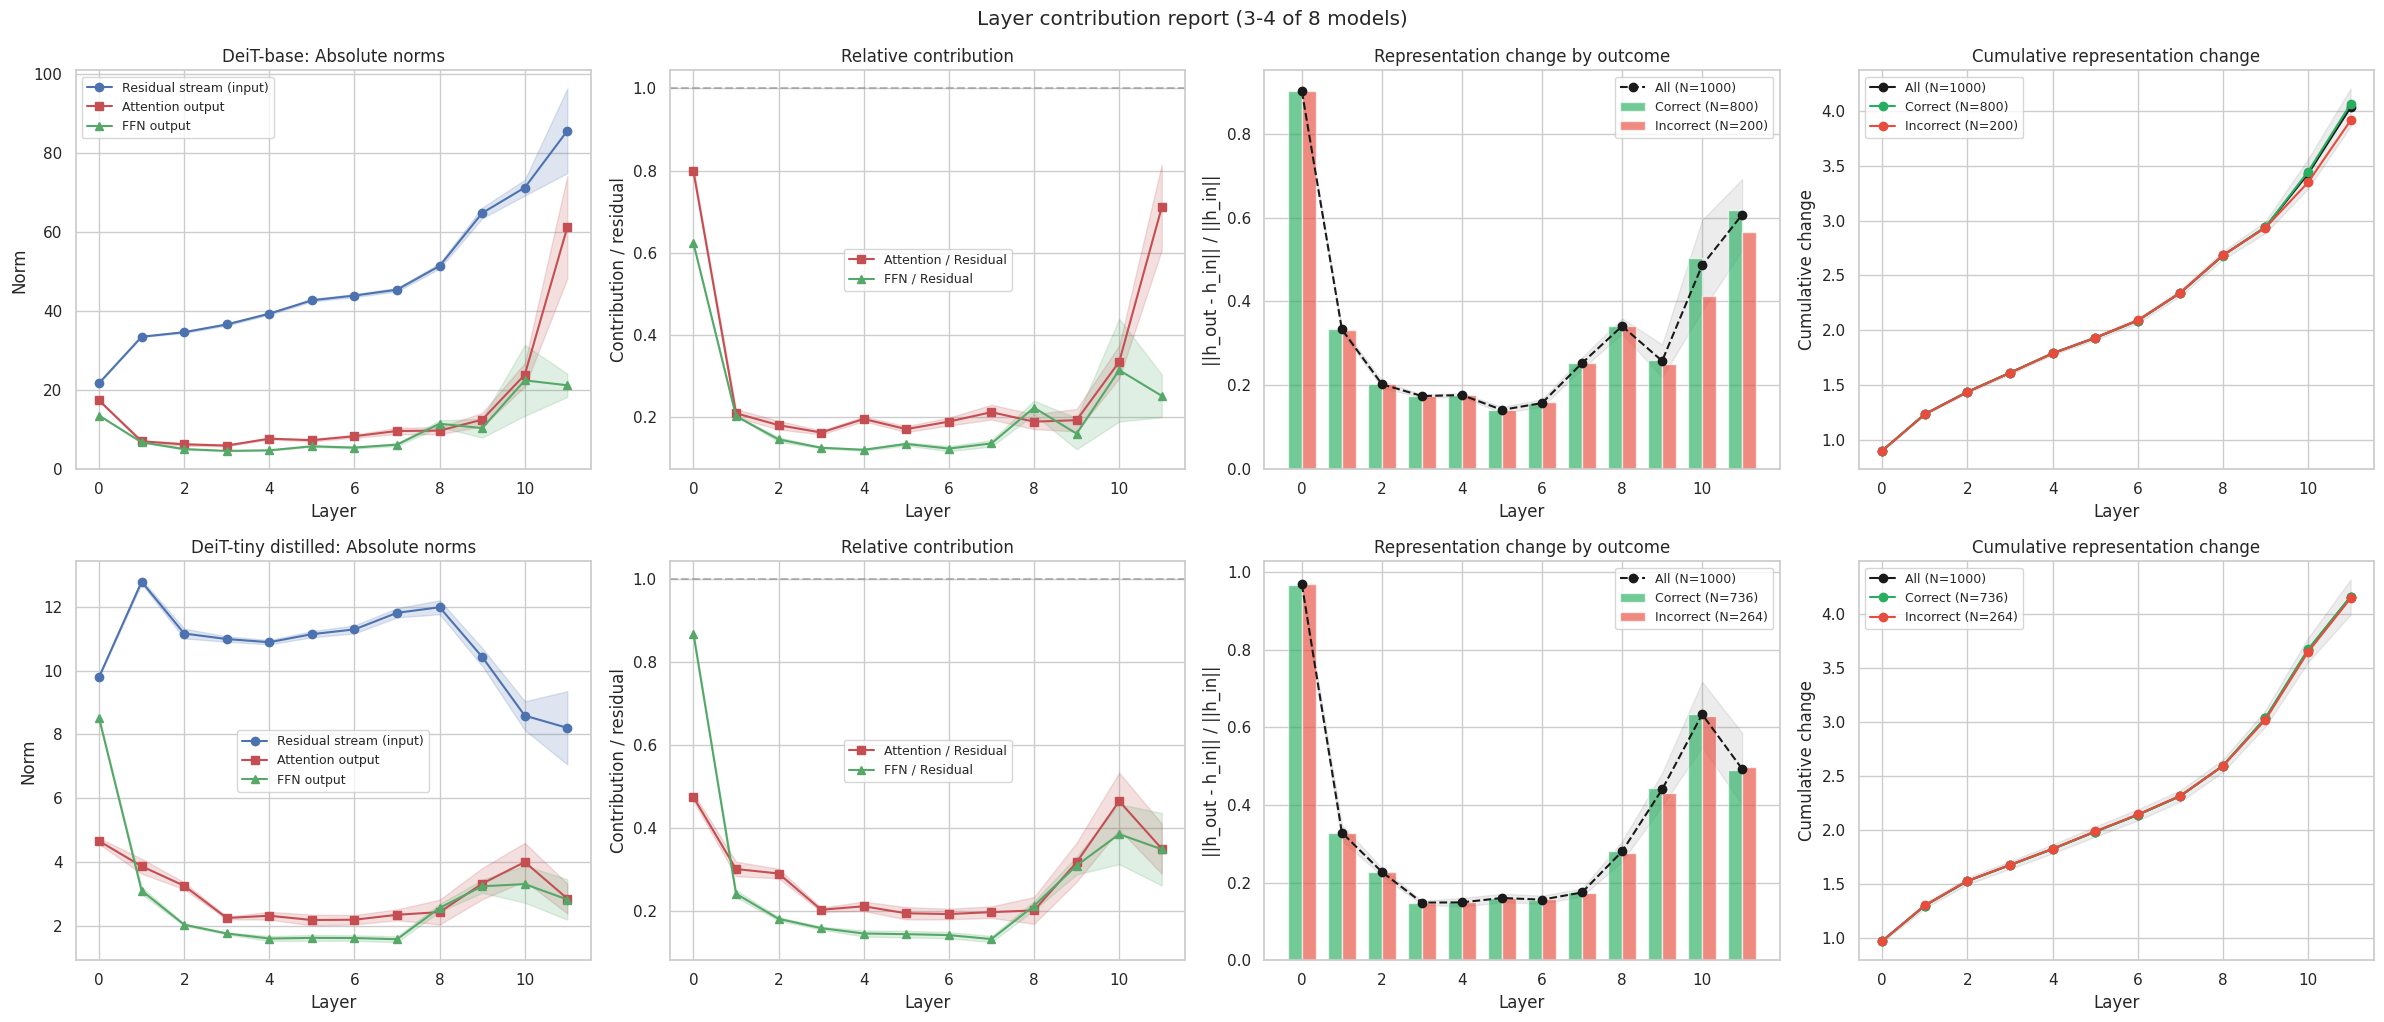

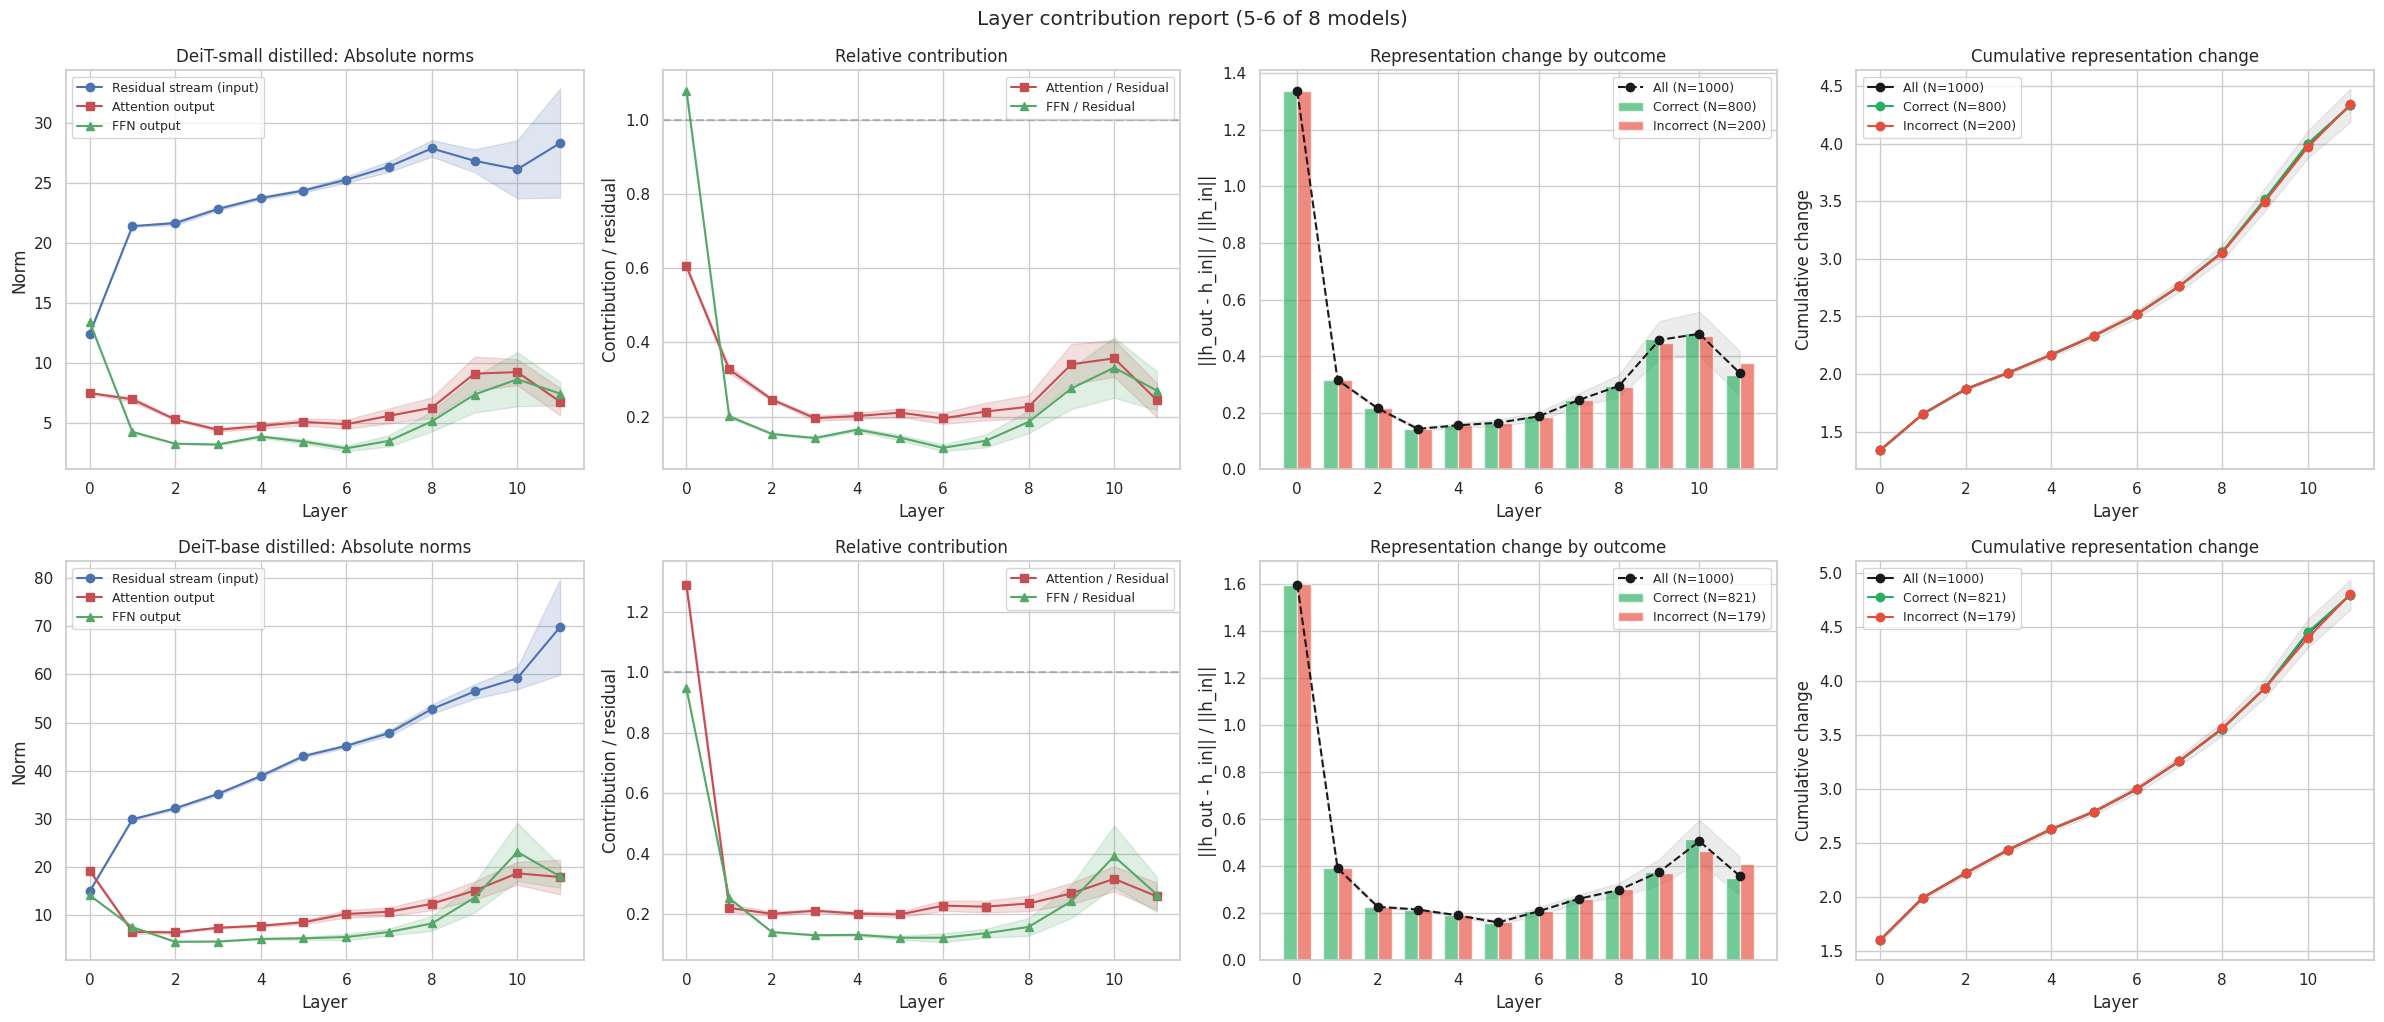

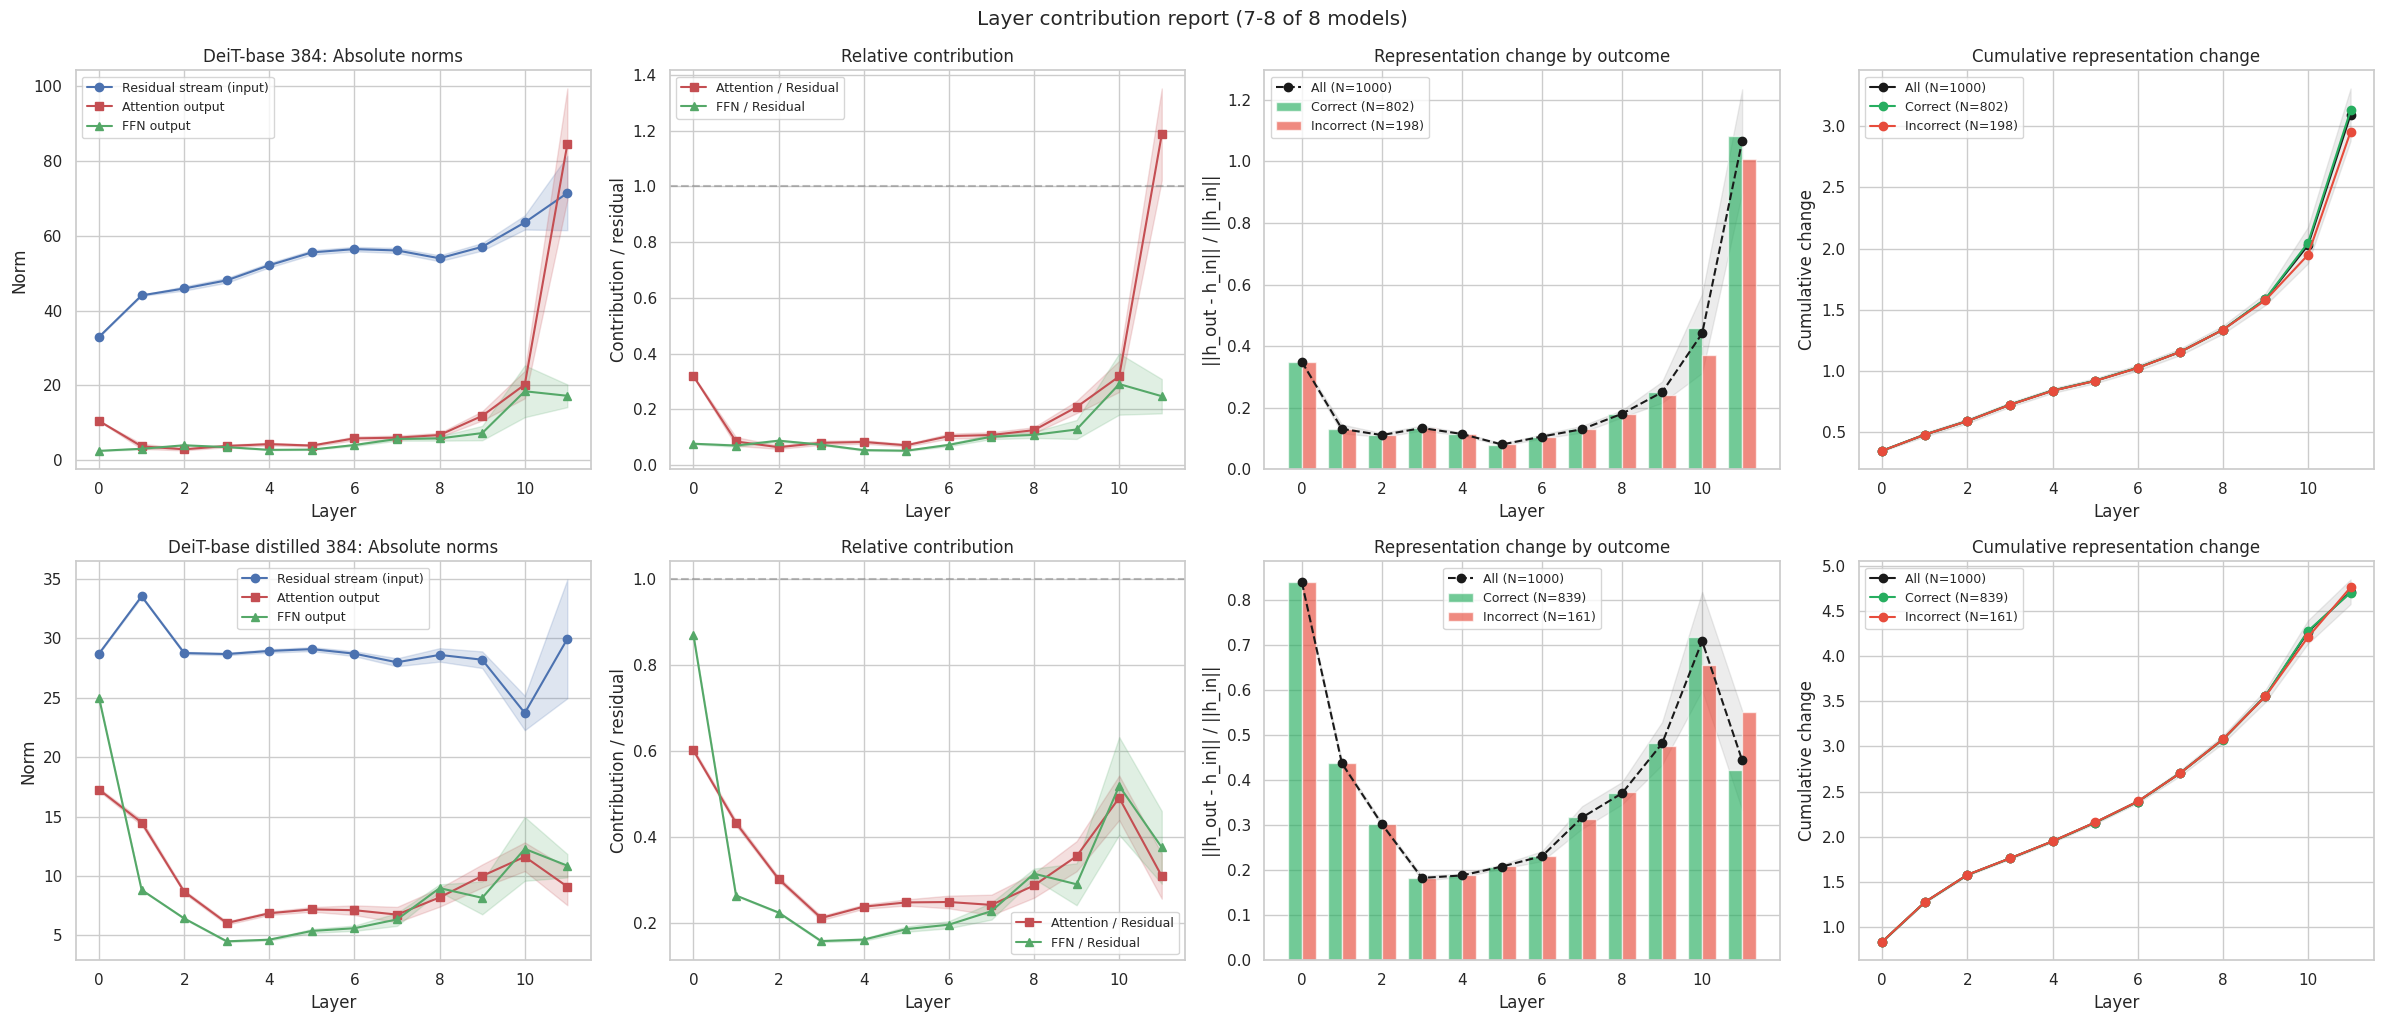

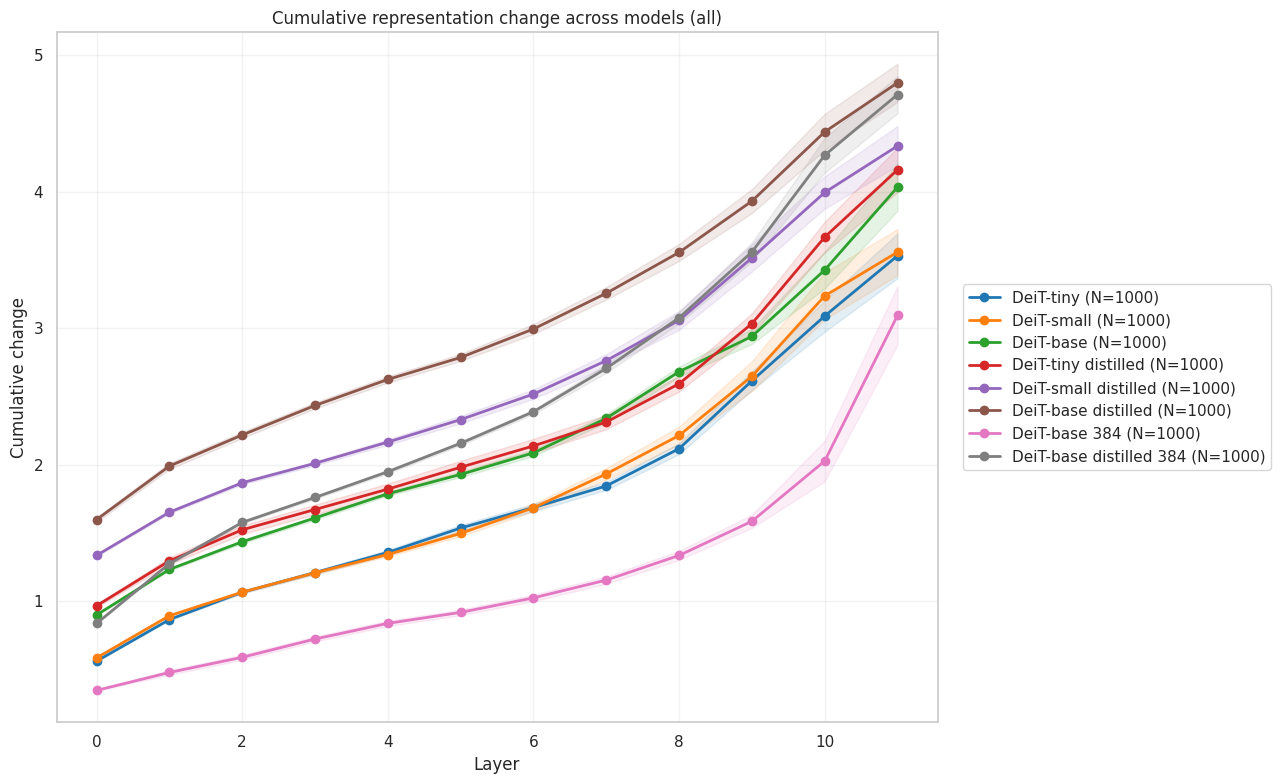

In [9]:
plot_layer_contribution_report(
    contribution_raw_df,
    selected_specs,
    models_per_figure=2,
)

plot_cumulative_representation_change_comparison(
    contribution_raw_df,
    selected_specs,
    split="all",
)

In [10]:
noise_robustness_df = run_noise_robustness_suite(
    model_specs=selected_specs,
    dataset_split=dataset_split,
    config=EXPERIMENT_CONFIG,
)

fragility_df = run_fragility_suite(
    model_specs=selected_specs,
    dataset_split=dataset_split,
    config=EXPERIMENT_CONFIG,
)

noise_robustness_df.head(), fragility_df.head()


Running noise robustness for DeiT-tiny...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Encoding accuracy batches:   0%|          | 0/32 [00:00<?, ?it/s]

Running noise robustness for DeiT-small...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Encoding accuracy batches:   0%|          | 0/32 [00:00<?, ?it/s]

Running layer fragility analysis for DeiT-base distilled 384...


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Encoding accuracy batches:   0%|          | 0/32 [00:00<?, ?it/s]

(  model_name                         repo_id target_layers  alpha  accuracy  \
 0  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.00     68.36   
 1  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.25     59.38   
 2  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.50     33.59   
 3  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   0.75      3.71   
 4  DeiT-tiny  facebook/deit-tiny-patch16-224    [8, 9, 10]   1.00      0.39   
 
    baseline_accuracy  accuracy_drop  samples_evaluated  
 0              68.36           0.00                500  
 1              68.36           8.98                500  
 2              68.36          34.77                500  
 3              68.36          64.65                500  
 4              68.36          67.97                500  ,
   model_name                         repo_id  layer  alpha  accuracy  \
 0  DeiT-tiny  facebook/deit-tiny-patch16-224      0   0.00     68.36   
 1  DeiT-tiny  facebook

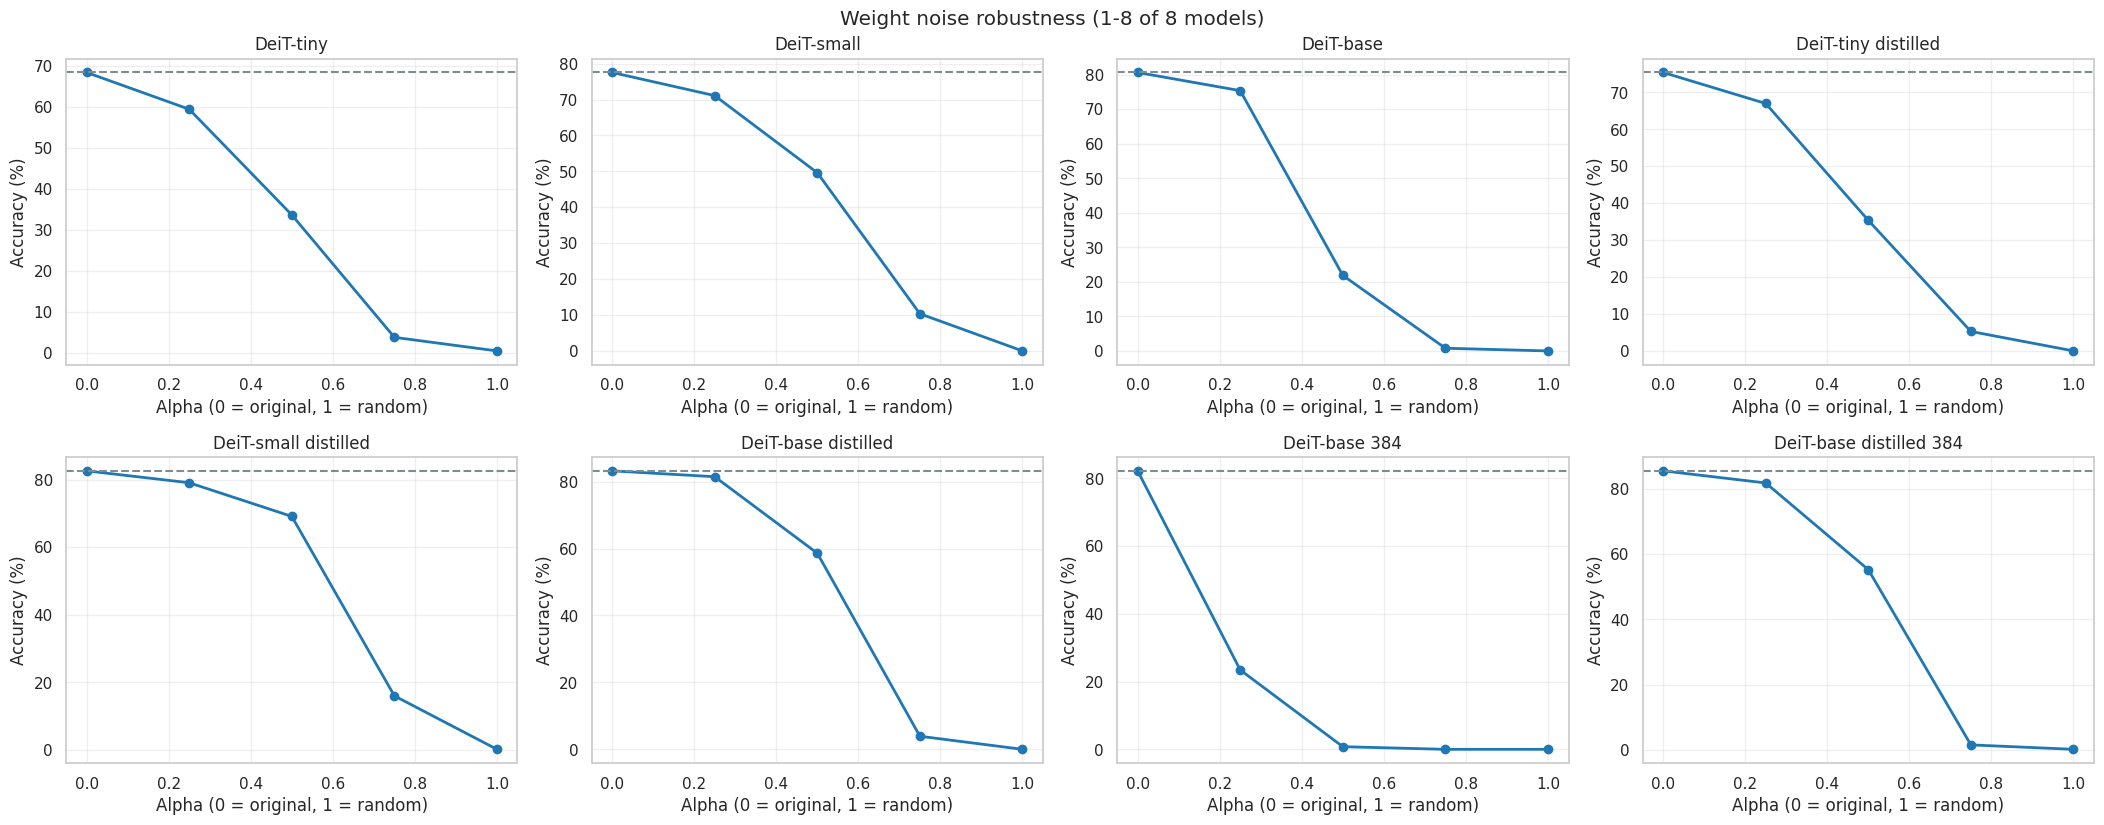

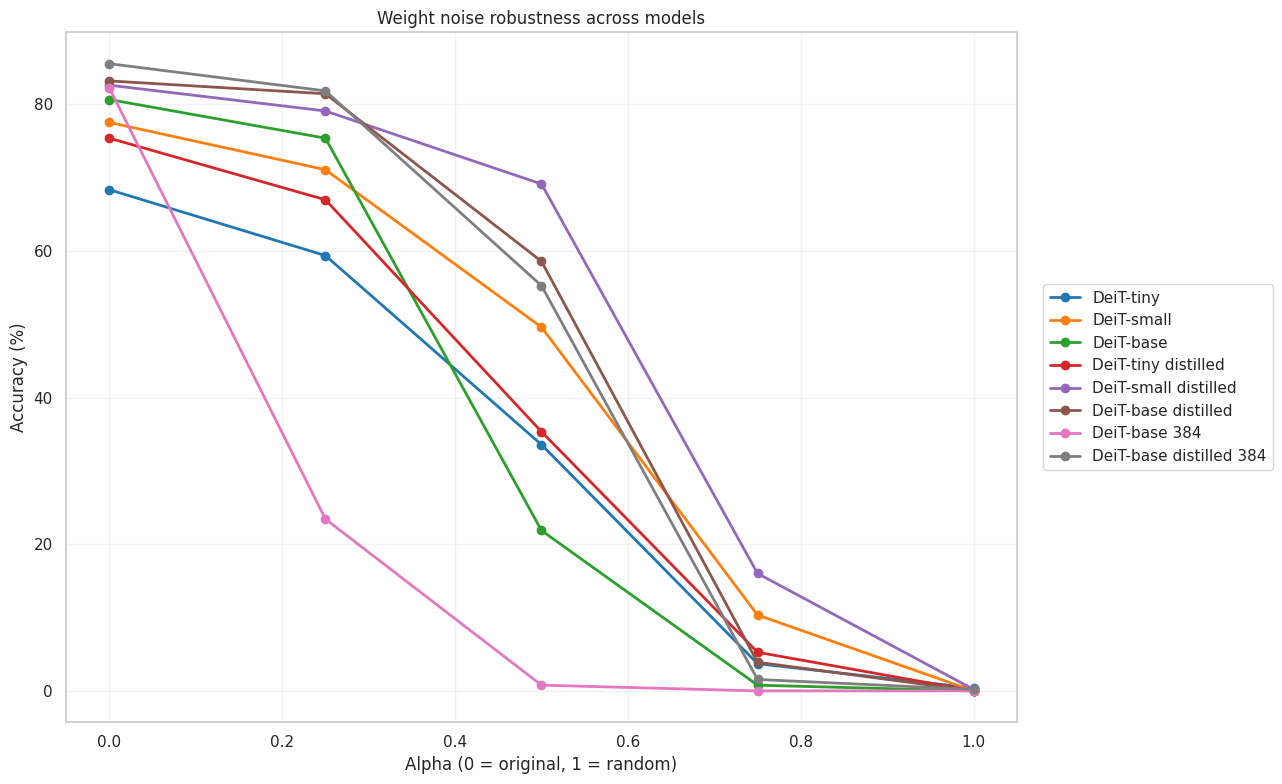

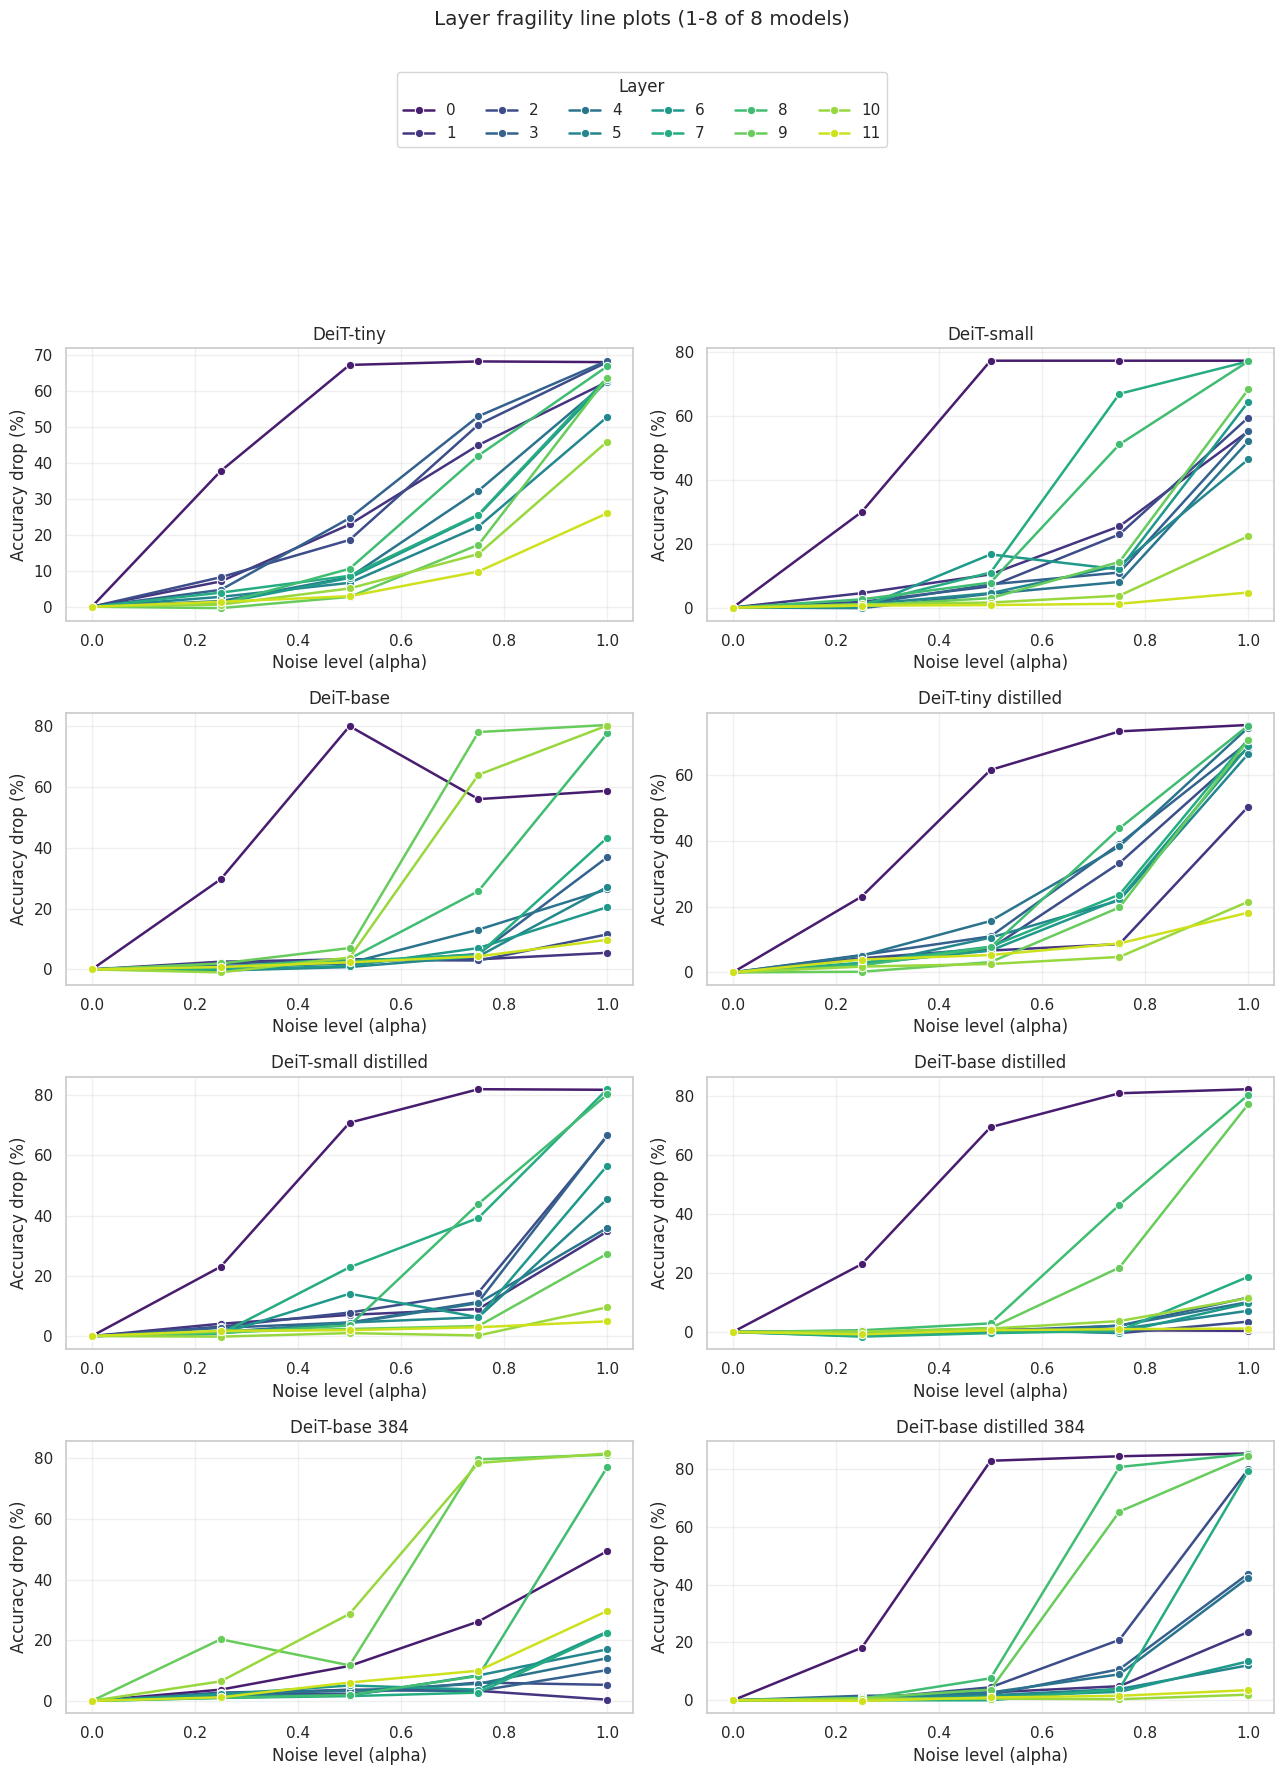

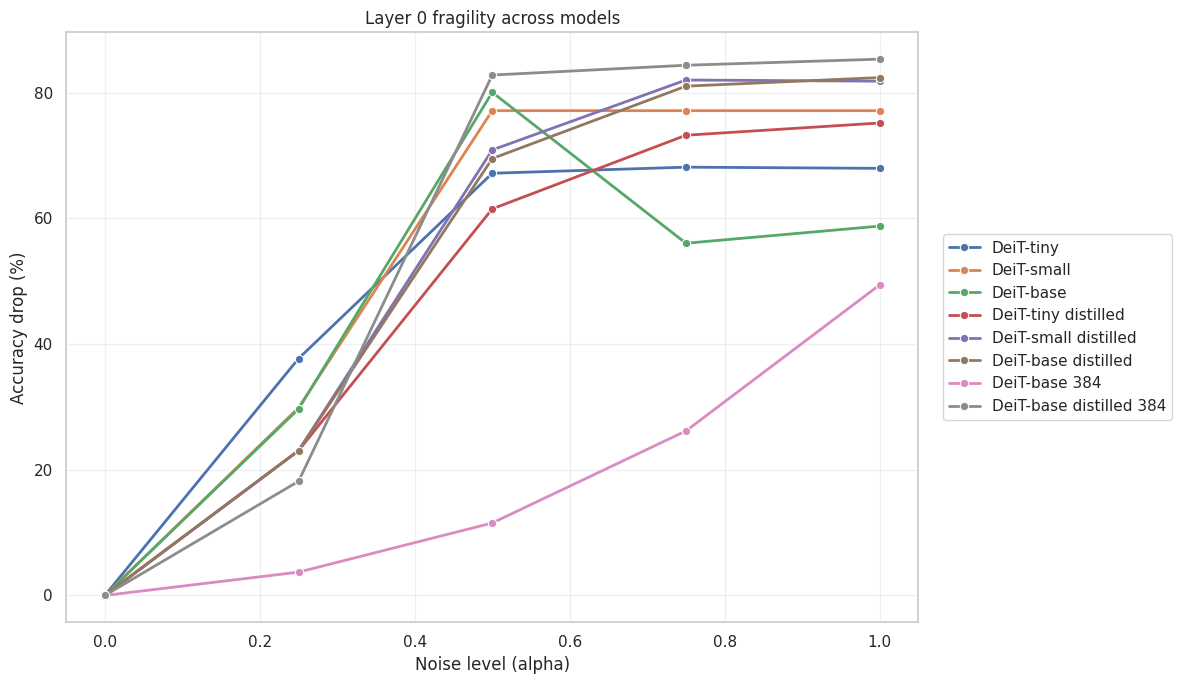

In [17]:
plot_weight_noise_robustness_report(
    noise_robustness_df,
    selected_specs,
    models_per_figure=8,
    n_cols=4,
)

plot_weight_noise_robustness_comparison(
    noise_robustness_df,
    selected_specs,
)

plot_fragility_line_report(
    fragility_df,
    selected_specs,
    models_per_figure=8,
    n_cols=2,
)

plot_fragility_layer_comparison(
    fragility_df,
    selected_specs,
    layer_idx=0,
)